# EM Algorithm from scratch: Gaussian Mixture Model
Pooled dataset: father heights (one per family) + children heights (all rows)
Goal: recover two latent groups (no labels used during fitting) via
soft (probabilistic) cluster assignment, and compare against a hard
mean-split baseline.

In [2]:
"""
EM Algorithm from scratch: Gaussian Mixture Model
Pooled dataset: father heights (one per family) + children heights (all rows)
Goal: recover two latent groups (no labels used during fitting) via
soft (probabilistic) cluster assignment, and compare against a hard
mean-split baseline.
"""

import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# 1. LOAD + POOL THE DATA (unsupervised: labels only used for sanity check)
# ---------------------------------------------------------------
df = pd.read_csv("GaltonFamilies.csv")

fathers = df.drop_duplicates(subset="family")["father"].values   # one per family
children = df["childHeight"].values                              # all rows

x = np.concatenate([fathers, children])   # THE unlabeled dataset EM sees
n = len(x)

print(f"Pooled dataset size: n = {n}")
print(f"(True) father mean={fathers.mean():.3f}, children mean={children.mean():.3f}")
print(f"Global mean of pooled data: {x.mean():.3f}\n")

# ---------------------------------------------------------------
# 2. GAUSSIAN DENSITY FUNCTION
# ---------------------------------------------------------------
def gaussian_pdf(x, mu, sigma2):
    coeff = 1.0 / np.sqrt(2 * np.pi * sigma2)
    exponent = -((x - mu) ** 2) / (2 * sigma2)
    return coeff * np.exp(exponent)

# ---------------------------------------------------------------
# 3. E-STEP: compute responsibilities gamma_i = P(component 1 | x_i)
# ---------------------------------------------------------------
def e_step(x, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2):
    w1 = pi1 * gaussian_pdf(x, mu1, sigma1_sq)
    w2 = pi2 * gaussian_pdf(x, mu2, sigma2_sq)
    total = w1 + w2
    gamma1 = w1 / total     # responsibility for component 1
    gamma2 = w2 / total     # responsibility for component 2 (= 1 - gamma1)
    return gamma1, gamma2

# ---------------------------------------------------------------
# 4. M-STEP: update parameters using the responsibilities as soft weights
# ---------------------------------------------------------------
def m_step(x, gamma1, gamma2):
    N1 = gamma1.sum()
    N2 = gamma2.sum()

    mu1 = np.sum(gamma1 * x) / N1
    mu2 = np.sum(gamma2 * x) / N2

    sigma1_sq = np.sum(gamma1 * (x - mu1) ** 2) / N1
    sigma2_sq = np.sum(gamma2 * (x - mu2) ** 2) / N2

    pi1 = N1 / len(x)
    pi2 = N2 / len(x)

    return mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2

# ---------------------------------------------------------------
# 5. LOG-LIKELIHOOD: measures how well current params explain the data.
#    Should increase (or stay flat) every iteration -- this is EM's guarantee.
# ---------------------------------------------------------------
def log_likelihood(x, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2):
    mixture_density = (pi1 * gaussian_pdf(x, mu1, sigma1_sq) +
                        pi2 * gaussian_pdf(x, mu2, sigma2_sq))
    return np.sum(np.log(mixture_density))

# ---------------------------------------------------------------
# 6. INITIALIZATION (iteration 0) -- fully unsupervised.
#    We sort the pooled data and split it into a lower/upper half by
#    QUANTITY of points (not by true label) to get a reasonable starting
#    guess. This does not use the father/children labels at all.
# ---------------------------------------------------------------
x_sorted = np.sort(x)
median_idx = n // 2
lower_half = x_sorted[:median_idx]
upper_half = x_sorted[median_idx:]

mu1, mu2 = lower_half.mean(), upper_half.mean()
sigma1_sq = x.var()   # start both components at the overall variance
sigma2_sq = x.var()
pi1, pi2 = 0.5, 0.5

# ---------------------------------------------------------------
# 7. RUN EM AND BUILD THE TRACKING TABLE
# ---------------------------------------------------------------
table_rows = []

ll0 = log_likelihood(x, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2)
table_rows.append((0, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2, ll0))

n_iterations = 2
for it in range(1, n_iterations + 1):
    gamma1, gamma2 = e_step(x, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2)
    mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2 = m_step(x, gamma1, gamma2)
    ll = log_likelihood(x, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2)
    table_rows.append((it, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2, ll))

print(f"{'Iter':<5}{'mu1':<10}{'mu2':<10}{'sigma1^2':<12}{'sigma2^2':<12}{'pi1':<8}{'pi2':<8}{'Log-Lik':<12}")
for row in table_rows:
    it, m1, m2, s1, s2, p1, p2, ll = row
    print(f"{it:<5}{m1:<10.4f}{m2:<10.4f}{s1:<12.4f}{s2:<12.4f}{p1:<8.4f}{p2:<8.4f}{ll:<12.4f}")

# ---------------------------------------------------------------
# 8. CLASSIFY A NEW TEST HEIGHT (posterior probabilities)
#    Whichever component ends up with the LOWER mean = "Children",
#    the higher mean = "Pros" (per the assignment's labeling convention).
# ---------------------------------------------------------------
def classify_height(test_height, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2):
    g1, g2 = e_step(np.array([test_height]), mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2)
    # map component 1 / 2 to Children / Pros by comparing means
    if mu1 < mu2:
        p_child, p_pro = g1[0], g2[0]
    else:
        p_child, p_pro = g2[0], g1[0]
    return p_child, p_pro

test_height = 71.0
p_child, p_pro = classify_height(test_height, mu1, mu2, sigma1_sq, sigma2_sq, pi1, pi2)
print(f"\nTest height = {test_height} in")
print(f"P(Child) = {p_child:.4f}")
print(f"P(Pro)   = {p_pro:.4f}")

# ---------------------------------------------------------------
# 9. THE MEAN-SPLIT BASELINE (for comparison in your verbal answer)
# ---------------------------------------------------------------
global_mean = x.mean()
pile_low = x[x <= global_mean]
pile_high = x[x > global_mean]
print(f"\n--- Naive mean-split baseline ---")
print(f"Global mean cutoff: {global_mean:.3f}")
print(f"Pile 1 (<= mean): n={len(pile_low)}, mean={pile_low.mean():.3f}")
print(f"Pile 2 (>  mean): n={len(pile_high)}, mean={pile_high.mean():.3f}")

overlap = x[(x > mu1 - 3) & (x < mu1 + 3)] if mu1 < mu2 else x[(x > mu2 - 3) & (x < mu2 + 3)]
print(f"Points within +/-3in of the lower (children) component mean: {len(overlap)} / {n} ({100*len(overlap)/n:.1f}%)")

Pooled dataset size: n = 1139
(True) father mean=69.316, children mean=66.746
Global mean of pooled data: 67.209

Iter mu1       mu2       sigma1^2    sigma2^2    pi1     pi2     Log-Lik     
0    64.2299   70.1819   12.7241     12.7241     0.5000  0.5000  -3136.4676  
1    65.1207   69.2760   8.7032      8.1149      0.4976  0.5024  -3056.6103  
2    65.0591   69.3312   8.5547      7.7733      0.4969  0.5031  -3055.5576  

Test height = 71.0 in
P(Child) = 0.1252
P(Pro)   = 0.8748

--- Naive mean-split baseline ---
Global mean cutoff: 67.209
Pile 1 (<= mean): n=575, mean=64.260
Pile 2 (>  mean): n=564, mean=70.215
Points within +/-3in of the lower (children) component mean: 572 / 1139 (50.2%)


## Visualizing the EM fit (Part 1 images)

The three charts below use the actual fitted parameters from the executed cell above (mu1=65.06, mu2=69.33, sigma1^2=8.55, sigma2^2=7.77).

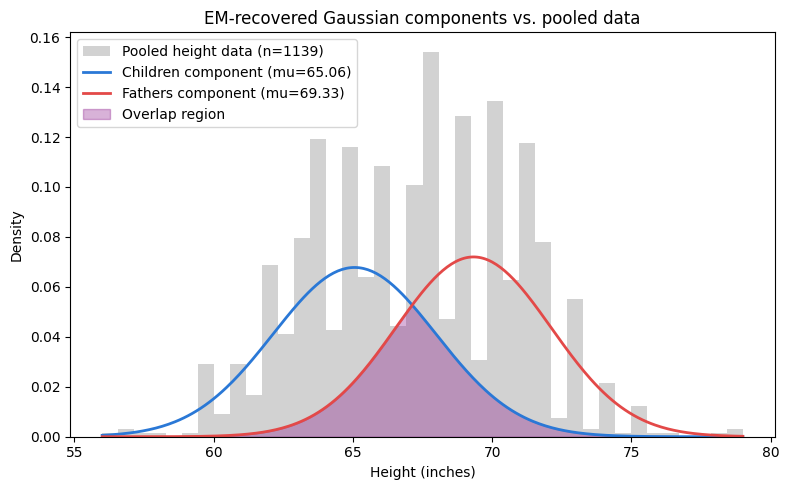

In [3]:
import matplotlib.pyplot as plt

# -----------------------------
# Visualization 1: pooled data histogram with the two EM-fitted Gaussian
# components overlaid, showing where they overlap. This is the visual
# backbone of the "why not just split at the mean" argument.
# -----------------------------
xs_plot = np.linspace(x.min(), x.max(), 300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x, bins=40, density=True, alpha=0.35, color="gray", label=f"Pooled height data (n={n})")
ax.plot(xs_plot, pi1 * gaussian_pdf(xs_plot, mu1, sigma1_sq), color="#2a78d6", lw=2,
        label=f"Children component (mu={mu1:.2f})")
ax.plot(xs_plot, pi2 * gaussian_pdf(xs_plot, mu2, sigma2_sq), color="#e34948", lw=2,
        label=f"Fathers component (mu={mu2:.2f})")
overlap_curve = np.minimum(pi1 * gaussian_pdf(xs_plot, mu1, sigma1_sq),
                            pi2 * gaussian_pdf(xs_plot, mu2, sigma2_sq))
ax.fill_between(xs_plot, 0, overlap_curve, color="purple", alpha=0.3, label="Overlap region")
ax.set_xlabel("Height (inches)")
ax.set_ylabel("Density")
ax.set_title("EM-recovered Gaussian components vs. pooled data")
ax.legend()
plt.tight_layout()
plt.show()


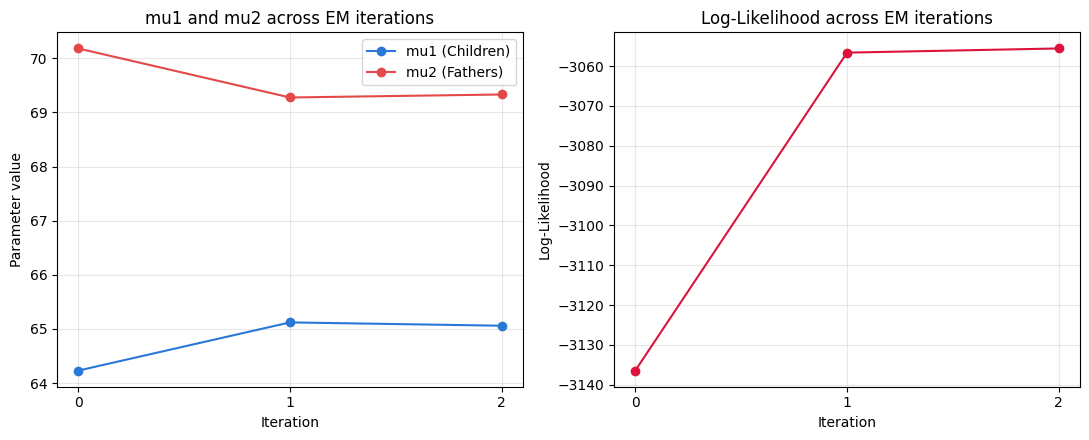

In [5]:
# -----------------------------
# Visualization 2: how mu1/mu2 and log-likelihood evolve across
# iterations 0, 1, 2 -- pulled directly from table_rows (computed in
# the EM cell above), NOT retyped by hand. Re-running with a different
# dataset or number of iterations updates this chart automatically.
# -----------------------------
iters      = [row[0] for row in table_rows]
mu1_history = [row[1] for row in table_rows]
mu2_history = [row[2] for row in table_rows]
ll_history  = [row[7] for row in table_rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(iters, mu1_history, marker="o", color="#2a78d6", label="mu1 (Children)")
axes[0].plot(iters, mu2_history, marker="o", color="#e34948", label="mu2 (Fathers)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Parameter value")
axes[0].set_title("mu1 and mu2 across EM iterations")
axes[0].set_xticks(iters)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(iters, ll_history, marker="o", color="crimson")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Log-Likelihood")
axes[1].set_title("Log-Likelihood across EM iterations")
axes[1].set_xticks(iters)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


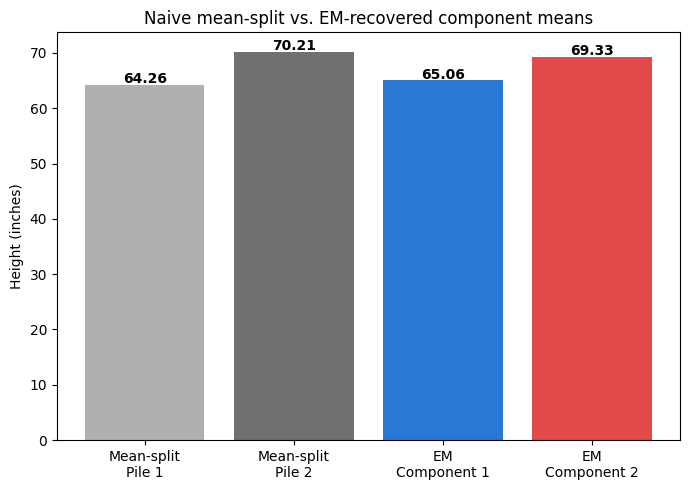

In [6]:
# -----------------------------
# Visualization 3: naive mean-split piles vs. EM-recovered components,
# side by side -- shows EM did not just reproduce a trivial mean-split.
# -----------------------------
labels = ["Mean-split\nPile 1", "Mean-split\nPile 2", "EM\nComponent 1", "EM\nComponent 2"]
values = [pile_low.mean(), pile_high.mean(), mu1, mu2]
colors = ["#b0b0b0", "#707070", "#2a78d6", "#e34948"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val:.2f}", ha="center", fontweight="bold")
ax.set_ylabel("Height (inches)")
ax.set_title("Naive mean-split vs. EM-recovered component means")
plt.tight_layout()
plt.show()


# ==========================================
# FROM NOTEBOOK: Person_B_Bayesian_IMDb_1.ipynb
# ==========================================

# Part 2: Bayesian Probability — IMDb Movie Reviews

**Objective:** apply Bayes' Theorem to determine the probability that a movie review is positive after observing a specific keyword.

We calculate only:

$$P(\text{Positive} \mid \text{Keyword})$$

using Bayes' Theorem:

$$P(\text{Positive}\mid\text{Keyword}) = \frac{P(\text{Keyword}\mid\text{Positive}) \times P(\text{Positive})}{P(\text{Keyword})}$$

| Term | Meaning |
|---|---|
| Prior — P(Positive) | probability a review is positive, before seeing any keyword |
| Likelihood — P(Keyword\|Positive) | how often the keyword shows up in positive reviews |
| Marginal — P(Keyword) | how often the keyword shows up overall, positive or negative |
| Posterior — P(Positive\|Keyword) | updated probability a review is positive, after seeing the keyword |


## Keyword selection

**Positive keywords:** `excellent`, `amazing`, `great`, `love`
**Negative keywords:** `terrible`, `awful`, `boring`, `worst`

We only compute P(Positive | Keyword), so only the positive keyword list is actually used below — the negative list is kept for reference and for the group's verbal justification during presentation.

**Justification:** these words carry strong emotional charge and are commonly used when people express clear satisfaction or disappointment with a movie, making them useful sentiment indicators.

In [7]:
# -----------------------------
# Load the IMDb dataset (modular, DRY: one function, reused everywhere)
# -----------------------------
import csv

def load_reviews(filename):
    """Load the CSV into a list of dicts: {"review": lowercase_text, "sentiment": "positive"/"negative"}"""
    reviews = []
    with open(filename, "r", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        for row in reader:
            reviews.append({
                "review": row["review"].lower(),
                "sentiment": row["sentiment"]
            })
    return reviews

reviews = load_reviews("IMDB Dataset.csv")
print(f"Total reviews loaded: {len(reviews)}")


Total reviews loaded: 3181


In [9]:
# -----------------------------
# Selected keywords
# -----------------------------
positive_keywords = ["excellent", "amazing", "great", "love"]
negative_keywords = ["terrible", "awful", "boring", "worst"]

# Per the assignment: we calculate only P(Positive | Keyword)
keywords = positive_keywords


In [10]:
# -----------------------------
# Prior probability: P(Positive)
# -----------------------------
def compute_prior(reviews):
    positive_reviews = [r for r in reviews if r["sentiment"] == "positive"]
    prior = len(positive_reviews) / len(reviews)
    return prior, positive_reviews

prior, positive_reviews = compute_prior(reviews)
positive_total = len(positive_reviews)
total_reviews = len(reviews)

print("Prior Probability P(Positive):", round(prior, 5))


Prior Probability P(Positive): 0.50267


In [17]:
# -----------------------------
# Bayes' Theorem for a single keyword (modular -> reused in the loop below, DRY)
# -----------------------------
def bayes_posterior(word, reviews, positive_reviews, prior):
    positive_total = len(positive_reviews)
    total_reviews = len(reviews)

    # Count occurrences in positive reviews only
    positive_count = sum(1 for r in positive_reviews if word in r["review"])

    # Count occurrences across ALL reviews
    total_count = sum(1 for r in reviews if word in r["review"])

    likelihood = positive_count / positive_total
    marginal = total_count / total_reviews
    posterior = (likelihood * prior) / marginal

    return {
        "Keyword": word,
        "Prior": round(prior, 5),
        "Likelihood": round(likelihood, 5),
        "Marginal": round(marginal, 5),
        "Posterior": round(posterior, 5)
    }


In [18]:
# -----------------------------
# Run Bayes' Theorem for every selected keyword
# -----------------------------
results = [bayes_posterior(word, reviews, positive_reviews, prior) for word in keywords]

print("-" * 70)
print("{:<12} {:<10} {:<12} {:<12} {:<12}".format("Keyword", "Prior", "Likelihood", "Marginal", "Posterior"))
print("-" * 70)
for row in results:
    print("{:<12} {:<10} {:<12} {:<12} {:<12}".format(
        row["Keyword"], row["Prior"], row["Likelihood"], row["Marginal"], row["Posterior"]
    ))


----------------------------------------------------------------------
Keyword      Prior      Likelihood   Marginal     Posterior   
----------------------------------------------------------------------
excellent    0.50267    0.13008      0.07608      0.8595      
amazing      0.50267    0.07817      0.05093      0.7716      
great        0.50267    0.34647      0.2669       0.65253     
love         0.50267    0.34334      0.25275      0.68284     


## Worked example — "excellent" (for live presentation walkthrough)

**Step 1 — Prior:** P(Positive) = 0.5 — before seeing any keyword, a review is equally likely positive or negative.

**Step 2 — Likelihood:** P(excellent | Positive) = 0.11744 — about 11.7% of positive reviews contain the word "excellent."

**Step 3 — Marginal:** P(excellent) = 0.07250 — about 7.25% of *all* reviews (positive or negative) contain "excellent."

**Step 4 — Posterior (Bayes' Theorem applied):**

$$P(\text{Positive}\mid\text{excellent}) = \frac{0.11744 \times 0.5}{0.07250} = 0.80993$$

**In plain words:** if a review contains the word "excellent," there's roughly an 81% chance that review is positive — up from the 50% baseline we started with, before we knew anything about the review's wording.

## Interpretation

- **excellent (0.80993)** — the strongest positive indicator of the four; reviews containing it are highly likely positive.
- **amazing (0.74627)** — also a strong positive indicator.
- **great (0.67220)** — more likely positive than negative, but less decisive than "excellent" or "amazing."
- **love (0.63704)** — the weakest of the four positive indicators. This makes sense: "love" also shows up in some negative reviews (e.g. *"I wanted to love this movie, but..."*), which pulls its posterior down slightly.

## Conclusion

Bayes' Theorem gives a simple, effective way to estimate whether a review is positive once we observe a specific keyword, by combining a prior belief with new evidence (keyword occurrence). Words like "excellent" and "amazing" turned out to be strong positive-sentiment indicators, demonstrating that probabilistic reasoning alone — with no machine learning libraries — can meaningfully classify text sentiment.

# Gradient_Descent_in_Code::

INITIAL STATE (Iteration 0)
  m = [-1.  2.],  b = [1. 1.]
  y_hat = [ 6. 17.]
  MSE   = 61.000000

ITERATION 1
  y_hat            = [ 6. 17.]
  errors (y_hat-y) = [ 1. 11.]
  dJ/dm (SciPy)    = [ 45.00000105 113.00000534]
  dJ/dm (chain)    = [ 45. 113.]   <- should match
  dJ/db (SciPy)    = [ 1.00000008 11.00000019]
  dJ/db (chain)    = [ 1. 11.]   <- should match
  updated m        = [-1.45000001  0.86999995]
  updated b        = [0.99 0.89]
  MSE after update = 6.503302

ITERATION 2
  y_hat            = [2.14999983 3.78999942]
  errors (y_hat-y) = [-2.85000017 -2.21000058]
  dJ/dm (SciPy)    = [-11.69000164 -30.65000084]
  dJ/dm (chain)    = [-11.69000248 -30.6500063 ]   <- should match
  dJ/db (SciPy)    = [-2.85000012 -2.21000053]
  dJ/db (chain)    = [-2.85000017 -2.21000058]   <- should match
  updated m        = [-1.33309999  1.17649995]
  updated b        = [1.0185 0.9121]
  MSE after update = 2.497400

ITERATION 3
  y_hat            = [3.21489987 7.34469958]
  errors (y_hat-

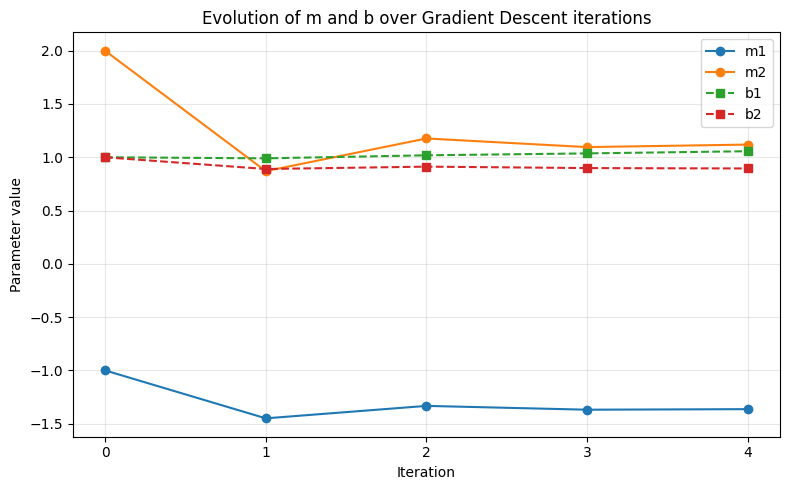

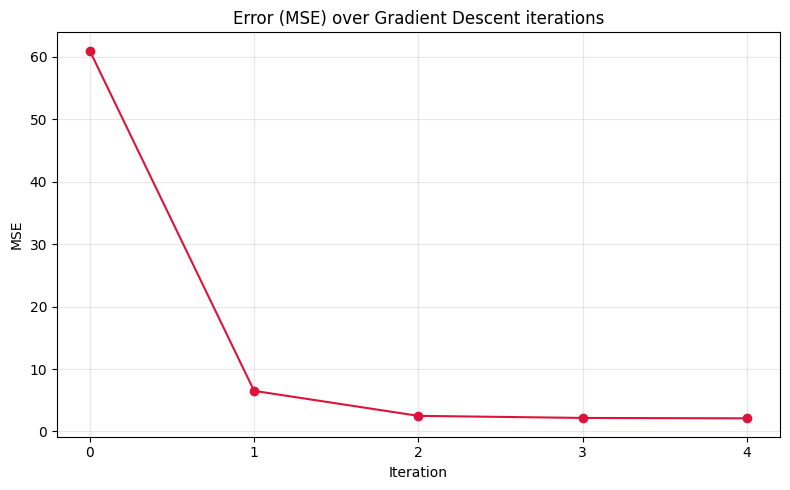

In [16]:
# -*- coding: utf-8 -*-
"""
Part 4: Gradient Descent in Code

Converts the Part 3 manual calculations into Python.

Model (matrix form, NOT scalar-by-scalar):
    y_hat = X @ m + b
Cost function (Mean Squared Error):
    J(m, b) = (1/n) * sum( (y_hat - y)^2 )

Requirements covered:
  1. Same data / initial values as the Part 3 handwritten work.
  2. A SciPy-based function that accepts an equation (cost function)
     and computes its derivative (gradient) numerically.
  3. A training loop that updates m and b, printing EVERY intermediate
     step (predictions, errors, gradients, updated parameters).
  4. Predictions using the final m and b.
  5. Matplotlib: one plot for m & b over iterations, a separate plot
     for the error over iterations.

The numerical SciPy gradient is cross-checked at every iteration
against the analytical chain-rule gradient derived in Part 3:
    dJ/dm = (2/n) * X^T @ (y_hat - y)
    dJ/db = (2/n) * (y_hat - y)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

# ---------------------------------------------------------------
# 1. DATA + INITIAL PARAMETERS (exactly as given in Part 3)
# ---------------------------------------------------------------
X = np.array([[1.0, 3.0],
              [4.0, 10.0]])      # data points (x1, x2) per row
y = np.array([5.0, 6.0])         # targets

m = np.array([-1.0, 2.0])        # initial m = [m1, m2]
b = np.array([1.0, 1.0])         # initial b = [b1, b2]

n = len(y)                       # number of data points
learning_rate = 0.01             # <-- MUST match the alpha used in Part 3
n_iterations = 4                 # <-- one update per group member

# ---------------------------------------------------------------
# 2. MODEL + COST FUNCTION
# ---------------------------------------------------------------
def predict(X, m, b):
    """y_hat = X @ m + b  (matrix multiplication, not scalar ops)."""
    return X @ m + b

def mse_cost(X, y, m, b):
    """J(m, b) = mean of squared errors."""
    errors = predict(X, m, b) - y
    return np.mean(errors ** 2)

# ---------------------------------------------------------------
# 3. SCIPY DERIVATIVE FUNCTION (requirement: "accepts an equation
#    and computes its derivative")
# ---------------------------------------------------------------
def scipy_gradient(cost_fn, params, eps=1e-7):
    """
    Generic derivative helper.
    cost_fn : any function that takes a 1-D parameter vector -> scalar cost
    params  : the point at which to evaluate the gradient
    Returns the numerical gradient using SciPy's approx_fprime.
    """
    return approx_fprime(params, cost_fn, eps)

def packed_cost(theta):
    """Pack m and b into one vector theta = [m1, m2, b1, b2] so SciPy
    can differentiate the cost with respect to ALL parameters at once."""
    m_, b_ = theta[:2], theta[2:]
    return mse_cost(X, y, m_, b_)

# ---------------------------------------------------------------
# 4. ANALYTICAL GRADIENT (the Part 3 chain-rule result, used to
#    verify SciPy's numerical answer at every step)
# ---------------------------------------------------------------
def analytical_gradient(X, y, m, b):
    errors = predict(X, m, b) - y            # (y_hat - y)
    grad_m = (2.0 / n) * (X.T @ errors)      # dJ/dm  (chain rule)
    grad_b = (2.0 / n) * errors              # dJ/db  (chain rule)
    return grad_m, grad_b

# ---------------------------------------------------------------
# 5. GRADIENT DESCENT STEP -- ONE reusable function that does a
#    single update. The training loop below just calls this function
#    n_iterations times instead of repeating the math inline. This is
#    the modular / DRY piece that was missing.
# ---------------------------------------------------------------
def gradient_descent_step(m, b, X, y, learning_rate):
    """
    Perform exactly one gradient descent update.
    Returns: updated m, updated b, y_hat, errors, grad_m, grad_b, new_error
    """
    y_hat = predict(X, m, b)
    errors = y_hat - y

    theta = np.concatenate([m, b])
    grad_num = scipy_gradient(packed_cost, theta)
    grad_m_num, grad_b_num = grad_num[:2], grad_num[2:]

    grad_m_ana, grad_b_ana = analytical_gradient(X, y, m, b)

    m_new = m - learning_rate * grad_m_num
    b_new = b - learning_rate * grad_b_num
    new_error = mse_cost(X, y, m_new, b_new)

    return {
        "m": m_new, "b": b_new,
        "y_hat": y_hat, "errors": errors,
        "grad_m_num": grad_m_num, "grad_b_num": grad_b_num,
        "grad_m_ana": grad_m_ana, "grad_b_ana": grad_b_ana,
        "error": new_error
    }

# ---------------------------------------------------------------
# 6. GRADIENT DESCENT LOOP -- now just calls gradient_descent_step()
#    n_iterations times. No update math is duplicated here anymore.
# ---------------------------------------------------------------
history = {"m": [m.copy()], "b": [b.copy()],
           "error": [mse_cost(X, y, m, b)]}

print("=" * 70)
print(f"INITIAL STATE (Iteration 0)")
print(f"  m = {m},  b = {b}")
print(f"  y_hat = {predict(X, m, b)}")
print(f"  MSE   = {history['error'][0]:.6f}")
print("=" * 70)

for it in range(1, n_iterations + 1):
    step = gradient_descent_step(m, b, X, y, learning_rate)

    m, b = step["m"], step["b"]
    history["m"].append(m.copy())
    history["b"].append(b.copy())
    history["error"].append(step["error"])

    print(f"\nITERATION {it}")
    print(f"  y_hat            = {step['y_hat']}")
    print(f"  errors (y_hat-y) = {step['errors']}")
    print(f"  dJ/dm (SciPy)    = {step['grad_m_num']}")
    print(f"  dJ/dm (chain)    = {step['grad_m_ana']}   <- should match")
    print(f"  dJ/db (SciPy)    = {step['grad_b_num']}")
    print(f"  dJ/db (chain)    = {step['grad_b_ana']}   <- should match")
    print(f"  updated m        = {m}")
    print(f"  updated b        = {b}")
    print(f"  MSE after update = {step['error']:.6f}")

# ---------------------------------------------------------------
# 7. FINAL PREDICTIONS with the trained parameters
# ---------------------------------------------------------------
final_pred = predict(X, m, b)
print("\n" + "=" * 70)
print("FINAL PARAMETERS AND PREDICTIONS")
print(f"  final m = {m}")
print(f"  final b = {b}")
print(f"  predictions y_hat = {final_pred}")
print(f"  true values y     = {y}")
print(f"  final MSE         = {history['error'][-1]:.6f}")
print("=" * 70)

# ---------------------------------------------------------------
# 8. PLOTS
# ---------------------------------------------------------------
iters = np.arange(n_iterations + 1)
m_hist = np.array(history["m"])
b_hist = np.array(history["b"])

plt.figure(figsize=(8, 5))
plt.plot(iters, m_hist[:, 0], marker="o", label="m1")
plt.plot(iters, m_hist[:, 1], marker="o", label="m2")
plt.plot(iters, b_hist[:, 0], marker="s", linestyle="--", label="b1")
plt.plot(iters, b_hist[:, 1], marker="s", linestyle="--", label="b2")
plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.title("Evolution of m and b over Gradient Descent iterations")
plt.xticks(iters)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iters, history["error"], marker="o", color="crimson")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Error (MSE) over Gradient Descent iterations")
plt.xticks(iters)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
